# 🎬 Netflix Data Analysis
This notebook explores the Netflix dataset to uncover insights about content trends, genres, ratings, and creators.


In [543]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns



## Loading the Dataset and Basic Exploration

In this section, we will load the Netflix dataset and perform some basic exploration to understand its structure and contents.


In [544]:
df = pd.read_csv('netflix_titles.csv')

In [545]:
rows , columns = df.shape
print(f'The dataset contains {rows} rows and {columns} columns.')

The dataset contains 8807 rows and 12 columns.


In [546]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [547]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [548]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [549]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [550]:
df.duplicated().sum()

0

## 🧹 Data Cleaning

In this section, we prepare the **Netflix dataset** for analysis by:
- Removing duplicates  
- Handling missing values  
- Converting columns to proper data types  
- Standardizing text and categorical values  
- Extracting new features such as *year added* and *duration type*

This ensures the dataset is consistent, complete, and ready for exploratory data analysis (EDA).


In [551]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='%B %d, %Y')
df['date_added'] = df['date_added'].fillna(pd.NaT)
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()


In [552]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('not available')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna('not rated')
df['duration'] = df['duration'].fillna('Unknown')

In [553]:
text_cols = ['type', 'country', 'rating', 'listed_in']
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

In [554]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,not available,United States,2021-09-25 00:00:00,2020,Pg-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00,2021,Tv-Ma,2 Seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24 00:00:00,2021,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",To protect his family from a powerful drug lor...,2021.0,September
3,s4,Tv Show,Jailbirds New Orleans,Unknown,not available,Unknown,2021-09-24 00:00:00,2021,Tv-Ma,1 Season,"Docuseries, Reality Tv","Feuds, flirtations and toilet talk go down amo...",2021.0,September
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00,2021,Tv-Ma,2 Seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",In a city of coaching centers known to train I...,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20 00:00:00,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,November
8803,s8804,Tv Show,Zombie Dumb,Unknown,not available,Unknown,2019-07-01 00:00:00,2018,Tv-Y7,2 Seasons,"Kids' Tv, Korean Tv Shows, Tv Comedies","While living alone in a spooky town, a young g...",2019.0,July
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01 00:00:00,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11 00:00:00,2006,Pg,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,January


In [555]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   object 
 1   type          8807 non-null   object 
 2   title         8807 non-null   object 
 3   director      8807 non-null   object 
 4   cast          8807 non-null   object 
 5   country       8807 non-null   object 
 6   date_added    8807 non-null   object 
 7   release_year  8807 non-null   int64  
 8   rating        8807 non-null   object 
 9   duration      8807 non-null   object 
 10  listed_in     8807 non-null   object 
 11  description   8807 non-null   object 
 12  year_added    8709 non-null   float64
 13  month_added   8709 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 963.4+ KB


## 📊 Exploratory Data Analysis (EDA)

In this section, we explore the cleaned **Netflix dataset** to uncover patterns, trends, and insights.  
The analysis focuses on understanding the distribution of content, release trends, genres, ratings, and geographical patterns.

Key objectives:
- Compare the number of **Movies vs TV Shows**
- Analyze **content growth over time**
- Identify the **top countries** producing content
- Explore the most common **genres** and **ratings**
- Highlight the most frequent **directors** and **actors**

Visualizations and summaries in this section help us understand Netflix’s content strategy and evolution.


In [556]:
sns.set_theme(
    style='whitegrid',
    context='talk',
    palette='mako',
    rc={
        'axes.spines.right': False,
        'axes.spines.top': False,
        'font.family': 'sans-serif'
    }
)

([<matplotlib.patches.Wedge at 0x273d3ab4a70>,
 [Text(-0.897672126570692, -0.6357552620136555, 'Movie'),
  Text(0.8976721265706921, 0.6357552620136554, 'Tv Show')],
 [Text(-0.4896393417658319, -0.3467755974619939, '69.6%'),
  Text(0.48963934176583196, 0.3467755974619938, '30.4%')])

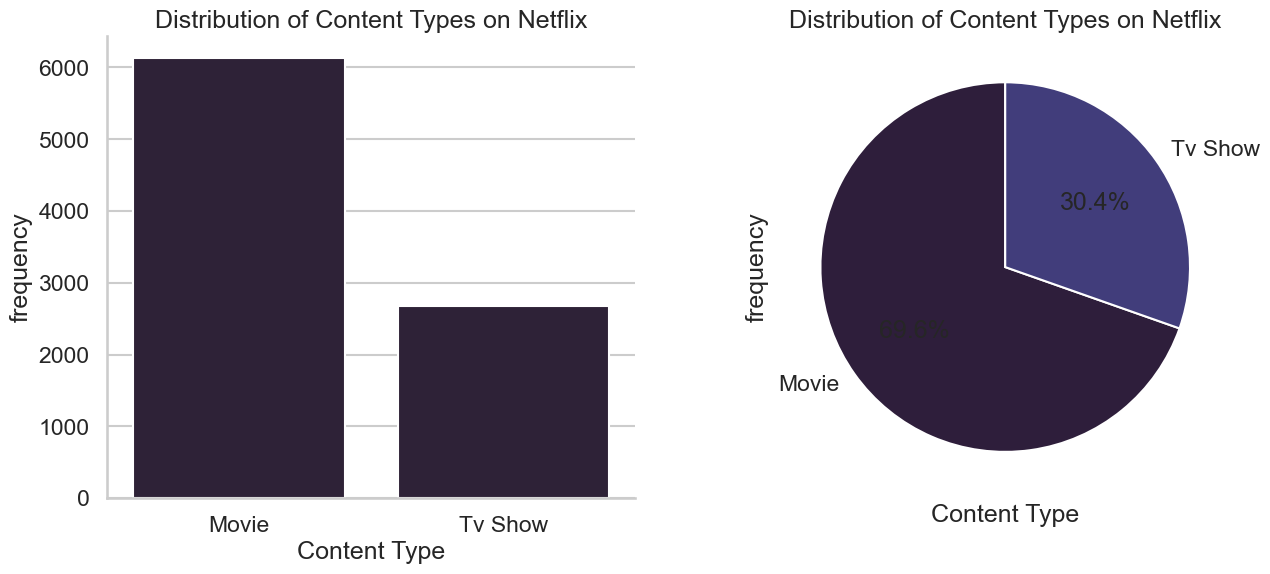

In [557]:
fig , axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].set_title('Distribution of Content Types on Netflix')
axes[0].set_xlabel('Content Type')
axes[0].set_ylabel('frequency')
sns.countplot(data=df, x='type', ax=axes[0])
axes[1].set_title('Distribution of Content Types on Netflix')
axes[1].set_xlabel('Content Type')
axes[1].set_ylabel('frequency')
axes[1].pie(df['type'].value_counts(), labels=df['type'].value_counts().index, autopct='%1.1f%%', startangle=90)


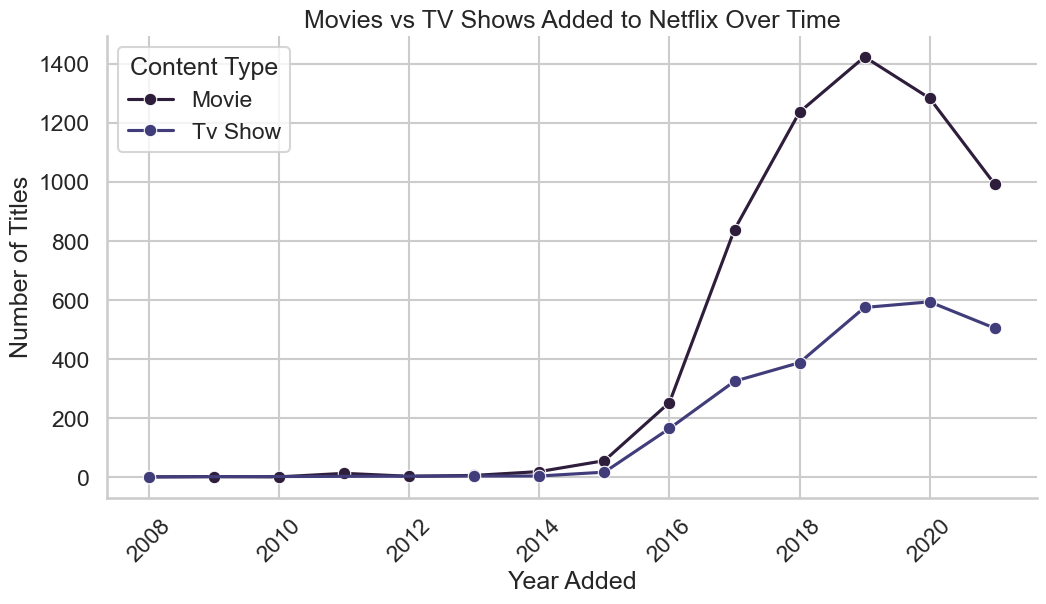

In [558]:
df2 = df.groupby(['year_added', 'type']).size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df2, x='year_added', y='count', hue='type', marker='o', ax=ax)
ax.set_title('Movies vs TV Shows Added to Netflix Over Time')
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')
plt.show()
# END: Line plot for Movies vs TV Shows across years

<Axes: title={'center': 'Top 10 Countries Producing Netflix Content'}, xlabel='Number of Titles', ylabel='Country'>

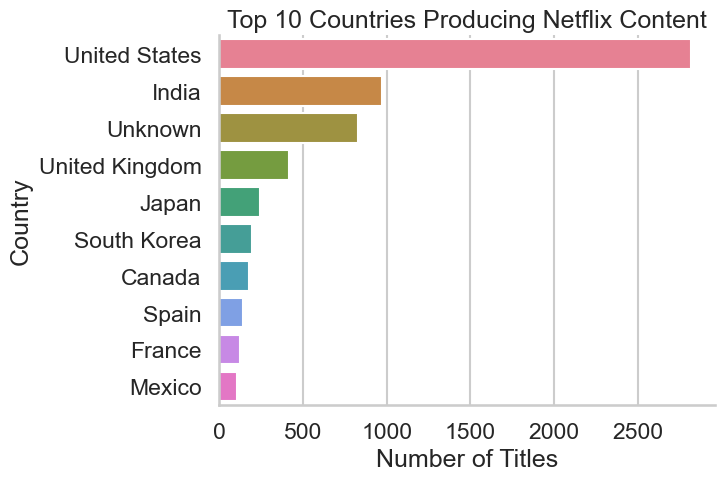

In [559]:
df3 = df['country'].value_counts().head(10)
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
sns.barplot(x=df3.values, y=df3.index , hue = df3.index, dodge=False)

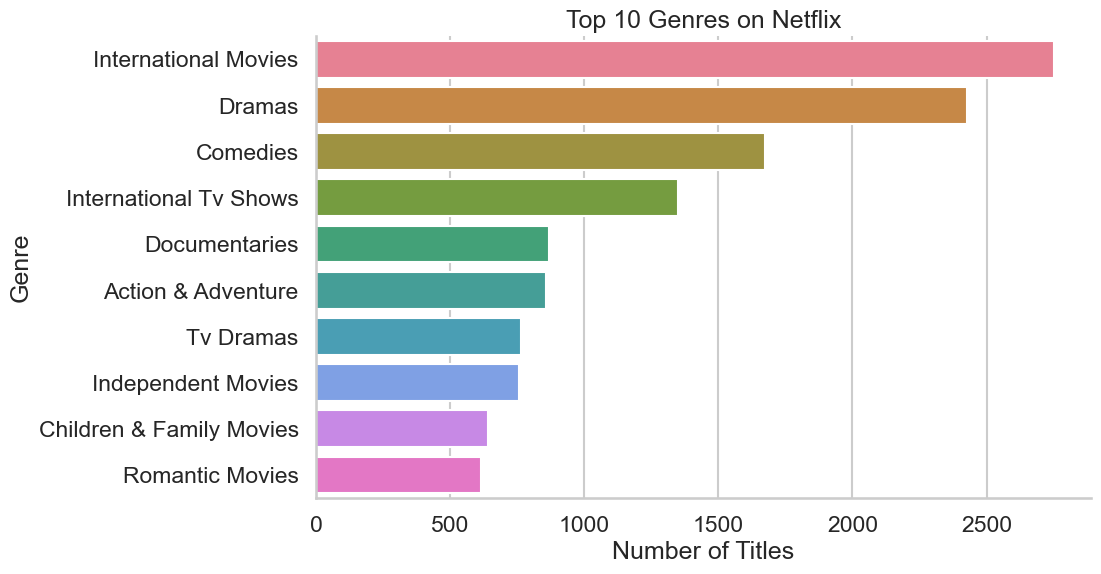

In [560]:
genre_df = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
top_genres = genre_df['genre'].value_counts().head(10).reset_index()
top_genres.columns = ['genre', 'count']
plt.figure(figsize=(10,6))
sns.barplot(data=top_genres, x='count', y='genre' , hue = 'genre')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

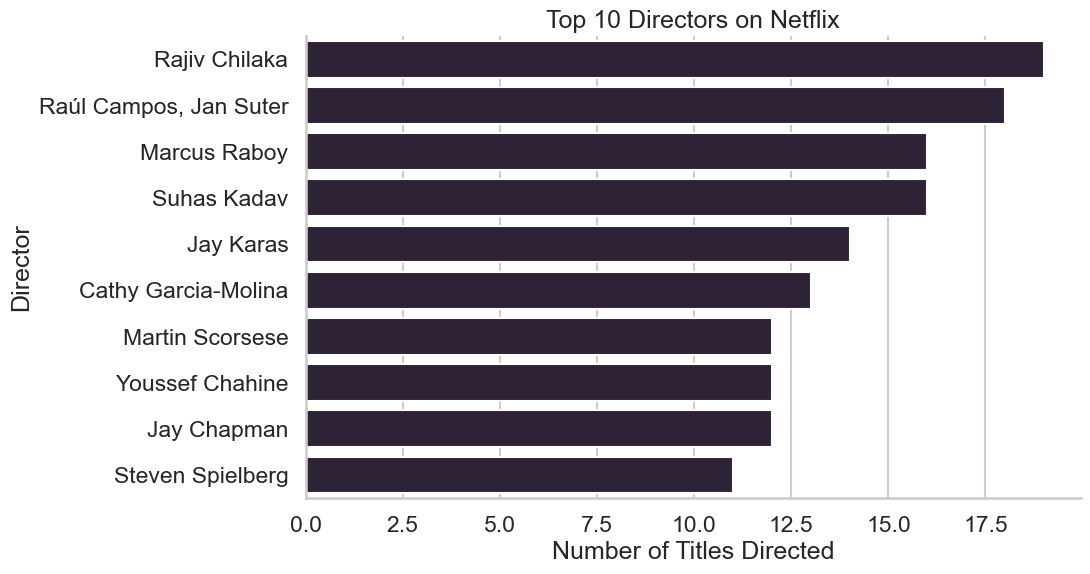

In [561]:
top_directors = (
    df[df['director'] != 'Unknown']
    ['director']
    .value_counts()
    .head(10)
    .reset_index()
)
top_directors.columns = ['Director', 'Number of Titles']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_directors, x='Number of Titles', y='Director')
plt.title('Top 10 Directors on Netflix')
plt.xlabel('Number of Titles Directed')
plt.ylabel('Director')
plt.show()


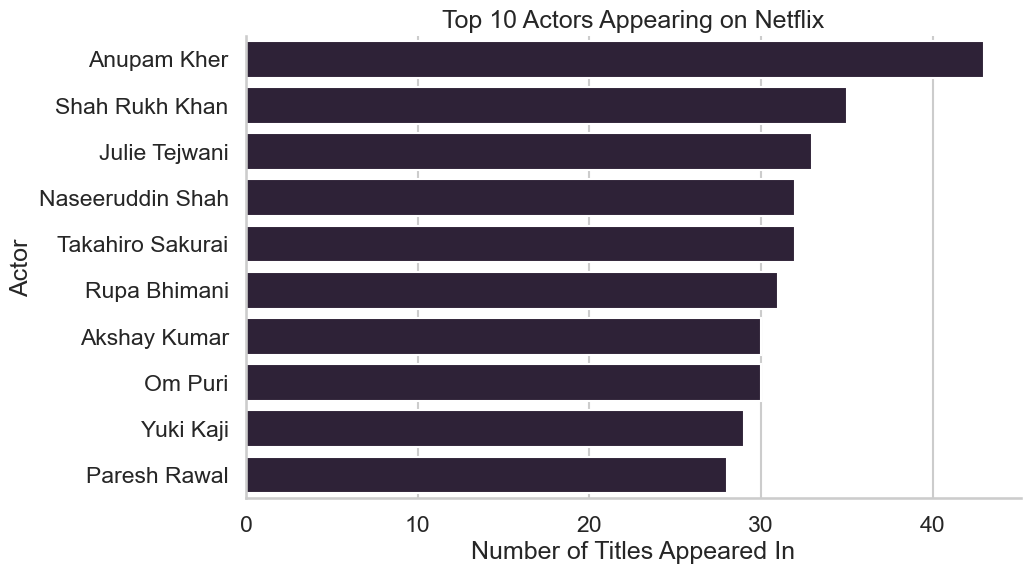

In [562]:
cast_df = df[df['cast'] != 'not available'].copy()
cast_df = cast_df.assign(Actor=cast_df['cast'].str.split(', ')).explode('Actor')

top_actors = (
    cast_df['Actor']
    .value_counts()
    .head(10)
    .reset_index()
)
top_actors.columns = ['Actor', 'Number of Titles']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_actors, x='Number of Titles', y='Actor')
plt.title('Top 10 Actors Appearing on Netflix')
plt.xlabel('Number of Titles Appeared In')
plt.ylabel('Actor')
plt.show()